# GCAP3226 Week 3 — Graded in-class exercise (5%)

**Individual** · submit via **your GitHub fork** (end of notebook). Keep answers short.

### What is marked
| Task | Focus |
|------|--------|
| **1** | Stacked bar: one factor **other than** `government_consideration` vs `support_info` + your trend description |
| **2** | Multiple linear regression that builds on the demo, adding `policy_helpfulness` and `waste_severity` + short coefficient interpretation |
| **3** | **Your own** IPO prompt → simple linear regression: `support_info` vs `fairness` |
| **Submit** | Save → Source Control → **Commit & Push** → **commit message** → Commit → Moodle **GitHub URL** |

Use **association** language only. This is a **non-probability** sample — do not claim causation or “all of Hong Kong”.


## How to use AI here (Codespaces)

In the demo you practiced **Input → Process → Output** prompts (**Write Python code** in Process).

**Tasks 1–2:** the prompt is already in the code cell as comments.

**Task 3:** you **write the prompt yourself** in the comments, then use Inline Chat.

Workflow:
1. Click inside the code cell.  
2. Edit / write the comment prompt.  
3. Press **`Cmd+I`** (Mac) or **`Ctrl+I`** (Windows/Linux).  
4. Ask e.g. *Implement the prompt in the comments above* → **Keep**.  
5. Fix anything that breaks; write interpretations **in your own words**.


## Setup (run once)

Load `week3.csv`. Glance at the column names so you know what you can use.


In [1]:
# Setup — run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression

DATA_FILE = "week3.csv"


def load_week3_data():
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            print("Using data file:", p.resolve())
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Work in your Week 3 fork / Codespace."
    )


df = load_week3_data()
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()


Using data file: /workspaces/GCAP3226_week3/week3.csv
shape: (97, 12)
columns: ['ID', 'support_info', 'support_after_info', 'government_consideration', 'fairness', 'policy_helpfulness', 'waste_severity', 'recycling_effort', 'age_group', 'monthly_income', 'education', 'education_label']


,ID,support_info,support_after_info,government_consideration,fairness,policy_helpfulness,waste_severity,recycling_effort,age_group,monthly_income,education,education_label
0,1,1,1,1,1,1,3,1,29.5,22500.5,4,Master or above
1,2,5,5,5,5,4,2,2,39.5,7500.0,4,Master or above
2,3,3,5,4,5,2,3,1,29.5,22500.5,4,Master or above
3,4,1,2,1,2,2,3,2,29.5,60000.5,4,Master or above
4,5,1,3,3,4,1,3,2,49.5,22500.5,2,Secondary


## Task 1 — Stacked bar (not the demo pair)

In the demo, the stacked bar used **`government_consideration`** (groups) × **`support_info`** (stack, row %).

**Your job:** choose a **different** grouping variable from `week3.csv` and plot a **row-% stacked bar** of `support_info` within each group.

### Suggested grouping variables (pick one)
| Variable | Notes |
|----------|--------|
| `fairness` | 1–5 |
| `policy_helpfulness` | 1–4 |
| `waste_severity` | 1–4 |
| `recycling_effort` | 1–4 |
| `education` | 1–4 |

Do **not** use `government_consideration` as the grouping variable.

In the **next code cell**, replace `<YOUR_GROUP_VAR>` in the comment prompt with your choice, then use Inline Chat (see **How to use AI** above).


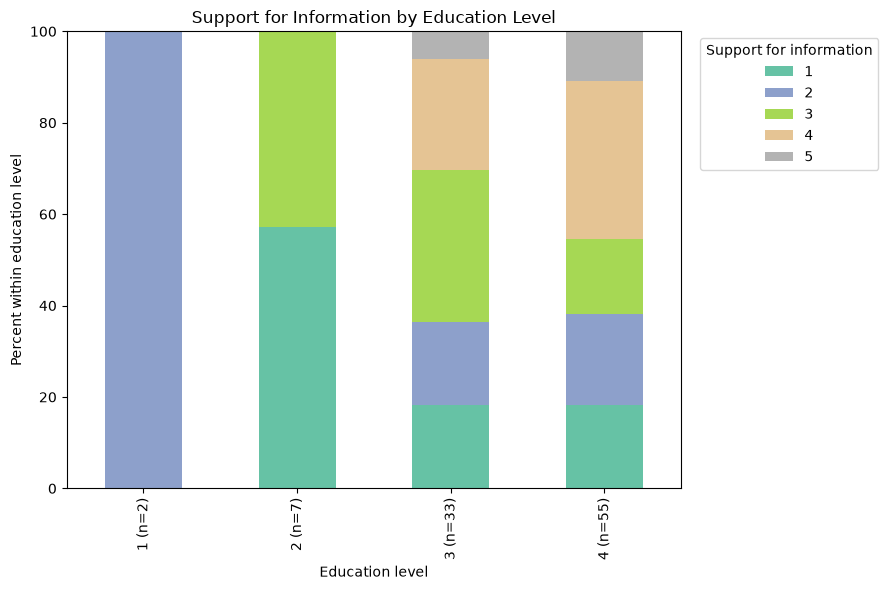

In [2]:
# Task 1 — Stacked bar
# Input: dataframe df already loaded from week3.csv.
# Process: Plot row percentages of support_info within each education level.
# Output: A stacked bar chart with group counts shown on the x-axis.

# Keep only rows with both variables needed for the chart.
chart_data = df[["education", "support_info"]].dropna()

# Count each support_info response within education and convert rows to percentages.
counts = pd.crosstab(chart_data["education"], chart_data["support_info"])
row_percentages = counts.div(counts.sum(axis=1), axis=0) * 100

# Include the number of observations in each education group on the x-axis.
group_sizes = chart_data.groupby("education").size()
row_percentages.index = [f"{education} (n={group_sizes.loc[education]})" for education in row_percentages.index]

# Draw the row-percentage stacked bar chart.
ax = row_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6),
    colormap="Set2",
)
ax.set_title("Support for Information by Education Level")
ax.set_xlabel("Education level")
ax.set_ylabel("Percent within education level")
ax.set_ylim(0, 100)
ax.legend(title="Support for information", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Task 1 — Describe the trend (your words)

In 2–4 sentences: what pattern do you see in **this sample**? Use association language. Mention any thin groups (small *n*) if relevant.

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [4]:
# Task 1 — write BETWEEN the triple quotes, then RUN this cell
task1_trend = """
Lower support for information is associated with higher education levels. In this sample, everyone in education level 1 selected support level 2, while education level 4 has more responses at support levels 3 and 4. The education level 1 group is thin (n=2), so that pattern should be interpreted cautiously.
"""
print(task1_trend)


Lower support for information is associated with higher education levels. In this sample, everyone in education level 1 selected support level 2, while education level 4 has more responses at support levels 3 and 4. The education level 1 group is thin (n=2), so that pattern should be interpreted cautiously.



## Task 2 — Multiple linear regression (+ policy & severity)

In the demo you fitted multiple linear regression with `government_consideration` and `fairness` (and a fuller model with demographics).

**Your job:** fit a multiple linear regression for this sample:

**Response:** `support_info`  

**Exploratory variables (at least these four):**
- `government_consideration`
- `fairness`
- `policy_helpfulness`
- `waste_severity`

Use complete cases for these columns. Print **each coefficient**, **R²**, and **n**.  

In the **next code cell**, use the comment prompt with Inline Chat (see **How to use AI** above).


In [5]:
# Task 2 — Multiple linear regression
# Use the requested response and exploratory variables.
response = "support_info"
predictors = [
    "government_consideration",
    "fairness",
    "policy_helpfulness",
    "waste_severity",
]

# Drop rows that are missing any variable used in the regression.
regression_data = df[[response] + predictors].dropna()
X = regression_data[predictors]
y = regression_data[response]

# Fit the multiple linear regression model.
model = LinearRegression()
model.fit(X, y)

# Print the coefficients in a clear table, along with R-squared and sample size.
coefficient_table = pd.DataFrame({"variable": predictors, "coefficient": model.coef_})
print(coefficient_table.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.4f}")
print(f"R-squared: {model.score(X, y):.4f}")
print(f"n: {len(regression_data)}")

                variable  coefficient
government_consideration     0.483265
                fairness     0.378639
      policy_helpfulness     0.192414
          waste_severity     0.117967

Intercept: -0.2768
R-squared: 0.6387
n: 97


### Task 2 — Report & briefly interpret

1. Paste or list the **coefficients** (and R², n) from your output.  
2. In a few sentences, interpret **two** coefficients that interest you (association; holding the other variables fixed).  
3. One caution (sample / overclaim).

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [7]:
# Task 2 — write BETWEEN the triple quotes, then RUN this cell
task2_writeup = """
Coefficients:
- government_consideration: 0.483265
- fairness: 0.378639
- policy_helpfulness: 0.192414
- waste_severity: 0.117967

Intercept: -0.2768
R-squared: 0.6387
n: 97

Government consideration and fairness have the largest coefficients in this model. Holding the other variables fixed, higher government consideration and fairness are associated with higher support for information. However, this analysis is based on a sample and does not imply causation; the smaller coefficients should not automatically be treated as useless or unreliable.
"""
print(task2_writeup)


Coefficients:
- government_consideration: 0.483265
- fairness: 0.378639
- policy_helpfulness: 0.192414
- waste_severity: 0.117967

Intercept: -0.2768
R-squared: 0.6387
n: 97

Government consideration and fairness have the largest coefficients in this model. Holding the other variables fixed, higher government consideration and fairness are associated with higher support for information. However, this analysis is based on a sample and does not imply causation; the smaller coefficients should not automatically be treated as useless or unreliable.



## Task 3 — Write your own prompt (simple linear regression)

**Goal:** `support_info` (response) vs `fairness` (one exploratory variable) — a **simple** linear regression on this sample.

Unlike Tasks 1–2, **do not** copy a ready-made Process. In the **next code cell**, write the full **Input / Process / Output** in the comments (**Process** must include **Write Python code**), then use Inline Chat (see **How to use AI** above).

Keep the model to **these two variables only** (not the Task 2 multiple linear regression). You should get coefficients, R², and n.


In [9]:
# Task 3 — YOUR prompt
# --- Input → Process → Output prompt ---
# Input: dataframe df already loaded from week3.csv. This is a sample of observations.
# Process: Write Python code to run a simple linear regression using support_info
#   as the response variable and fairness as the only exploratory variable.
#   Drop rows with missing values in support_info or fairness. Fit the model,
#   then print the intercept, fairness coefficient, R-squared, and sample size n.
#   Add comments explaining the key steps. Use association language, not causation.
# Output: A clear report of the regression coefficient(s), intercept, R-squared,
#   and n for this sample.
# --- End prompt ---
# Requirement: simple linear regression only — response = support_info, exploratory = fairness.

# Keep only complete cases for the response and the one predictor.
simple_regression_data = df[["support_info", "fairness"]].dropna()
X_simple = simple_regression_data[["fairness"]]
y_simple = simple_regression_data["support_info"]

# Fit the simple linear regression model.
simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)

# Report the slope, intercept, R-squared, and sample size.
print(f"Fairness coefficient: {simple_model.coef_[0]:.4f}")
print(f"Intercept: {simple_model.intercept_:.4f}")
print(f"R-squared: {simple_model.score(X_simple, y_simple):.4f}")
print(f"n: {len(simple_regression_data)}")

Fairness coefficient: 0.7936
Intercept: 0.4950
R-squared: 0.5219
n: 97


### Task 3 — Short note

In 1–2 sentences: what does the **fairness** slope mean in this simple linear regression? How does it compare (roughly) with the fairness coefficient in your **Task 2** multiple linear regression?

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell.


In [11]:
# Task 3 — write BETWEEN the triple quotes, then RUN this cell
task3_note = """
The fairness coefficient is 0.7936, so fairness is positively associated with support for information in this sample. Holding only fairness in the model, a one-point increase in fairness is associated with an estimated 0.7936-point increase in support for information. This association is larger than the fairness coefficient in the Task 2 multiple regression (0.3786), but neither result demonstrates causation.
"""
print(task3_note)


The fairness coefficient is 0.7936, so fairness is positively associated with support for information in this sample. Holding only fairness in the model, a one-point increase in fairness is associated with an estimated 0.7936-point increase in support for information. This association is larger than the fairness coefficient in the Task 2 multiple regression (0.3786), but neither result demonstrates causation.



## How to submit

Submit the **GitHub URL** of this notebook in **your fork** (not an `.ipynb` upload).

1. **Save** the notebook.  
2. Open **Source Control** (left sidebar, branch icon).  
3. Click **Commit & Push**.  
4. Type a **commit message** → click **Commit**.  
5. On github.com, open the file in **your fork** → copy the browser URL.  
6. Paste that URL on **Moodle**.

**If push fails:** ask a TA — keep working toward a push to your fork.

### Checklist
- [ ] Task 1: stacked bar (not `government_consideration` groups) + trend description  
- [ ] Task 2: multiple linear regression with the four required variables + coefficient write-up  
- [ ] Task 3: **your own** IPO prompt + simple linear regression (`support_info` vs `fairness`)  
- [ ] Saved → Commit & Push → commit message → Commit  
- [ ] Moodle: GitHub link submitted  
